## Cairo real estate:

- This dataset contains clean, structured real estate data for apartments located in Greater Cairo, Egypt. It consists of 5,578 records with no missing values, making it highly suitable for data analysis, visualization, and machine learning applications.

- The dataset captures detailed apartment characteristics along with multiple price representations, enabling accurate market insights and price prediction models.

## Location:

- Greater Cairo Area (Cairo, Giza, and surrounding districts)

##  Dataset Features:

# Each record represents one apartment and includes the following attributes:

- Price: Apartment price as listed (textual format)

- Price_Numeric: Cleaned numeric price value

- Area: Apartment area in square meters

- Rooms: Number of rooms

- Bathrooms: Number of bathrooms

- Floor Level: Apartment floor level

- Year Built: Construction year of the building

- Seller Type: Type of seller (owner, broker, developer, etc.)

- View: Apartment view (street, garden, open view, etc.)

- Payment Method: Payment type (cash, installments, etc.)

- Location: District or neighborhood

- Amenities: Available amenities (elevator, parking, security, etc.)

- Calculated_Price_Per_Meter: Calculated price per square meter

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandasql as psql

In [17]:
df = pd.read_csv("Apartments Prices Dataset.csv")

In [19]:
df

,price,area_sqm,rooms,bathrooms,floor_level,year_built,seller_type,view,price_per_sqm,payment_method,finishing_type
0,"2,163,000 EGP",120 m²,2 rooms,3 bathroom,3,2025,Developer,Main Street,"18,025 EGP/M²",Installments,Semi Finished
1,"3,250,000 EGP",162 m²,3 rooms,2 bathroom,6,2024,Developer,Main Street,"20,062 EGP/M²",Cash or Installments,Semi Finished
2,"2,650,000 EGP",122 m²,3 rooms,1 bathroom,4,2024,Developer,Main Street,"21,721 EGP/M²",Cash or Installments,Semi Finished
3,"12,720,000 EGP",212 m²,4 rooms,3 bathroom,13,2027,Broker,Club,"60,000 EGP/M²",Cash or Installments,Extra Super Lux
4,"5,898,000 EGP",135 m²,2 rooms,1 bathroom,6,2025,Developer,Lake,"43,689 EGP/M²",Cash or Installments,Super Lux
...,...,...,...,...,...,...,...,...,...,...,...
5573,"13,200,000 EGP",168 m²,3 rooms,3 bathroom,5,2028,Broker,Garden,"78,571 EGP/M²",Installments,Semi Finished
5574,"2,800,000 EGP",180 m²,3 rooms,2 bathroom,3,2019,Broker,Side Street,"15,556 EGP/M²",Cash,Extra Super Lux
5575,"6,000,000 EGP",215 m²,3 rooms,2 bathroom,7,2025,Broker,Other,"27,907 EGP/M²",Cash,Semi Finished
5576,"7,500,000 EGP",400 m²,4 rooms,3 bathroom,11,2009,Broker,Main Street,"18,750 EGP/M²",Cash,Super Lux


## Goal 1: Compare apartments according to their characteristics (Square area, Floor level, payment method, Rooms, Bathrooms, Finishing type)

In [28]:
characteristic = df[['view', 'area_sqm', 'floor_level', 'payment_method', 'rooms', 'bathrooms', 'finishing_type']]

In [30]:
characteristic

,view,area_sqm,floor_level,payment_method,rooms,bathrooms,finishing_type
0,Main Street,120 m²,3,Installments,2 rooms,3 bathroom,Semi Finished
1,Main Street,162 m²,6,Cash or Installments,3 rooms,2 bathroom,Semi Finished
2,Main Street,122 m²,4,Cash or Installments,3 rooms,1 bathroom,Semi Finished
3,Club,212 m²,13,Cash or Installments,4 rooms,3 bathroom,Extra Super Lux
4,Lake,135 m²,6,Cash or Installments,2 rooms,1 bathroom,Super Lux
...,...,...,...,...,...,...,...
5573,Garden,168 m²,5,Installments,3 rooms,3 bathroom,Semi Finished
5574,Side Street,180 m²,3,Cash,3 rooms,2 bathroom,Extra Super Lux
5575,Other,215 m²,7,Cash,3 rooms,2 bathroom,Semi Finished
5576,Main Street,400 m²,11,Cash,4 rooms,3 bathroom,Super Lux


In [35]:
area = characteristic.groupby('view')['area_sqm'].describe()

## Describe: A command that describes the details of a specific analysis.

In [37]:
area

,count,unique,top,freq
view,,,,
Back,97,36,73 m²,9
Club,17,12,212 m²,2
Corner,148,53,140 m²,13
Garden,1272,192,130 m²,51
Golf Course,6,5,156 m²,2
Lake,54,31,133 m²,5
Main Street,1725,196,150 m²,62
Nile View,13,8,110 m²,3
Other,551,133,130 m²,28


In [58]:
area_count = area.sort_values(by = 'count', ascending = False)

In [60]:
area_count

,count,unique,top,freq
view,,,,
Main Street,1725,196,150 m²,62
Garden,1272,192,130 m²,51
Pool,734,102,58 m²,41
Side Street,714,106,140 m²,61
Other,551,133,130 m²,28
Sea View,174,61,72 m²,37
Corner,148,53,140 m²,13
Back,97,36,73 m²,9
Plaza,73,28,158 m²,7


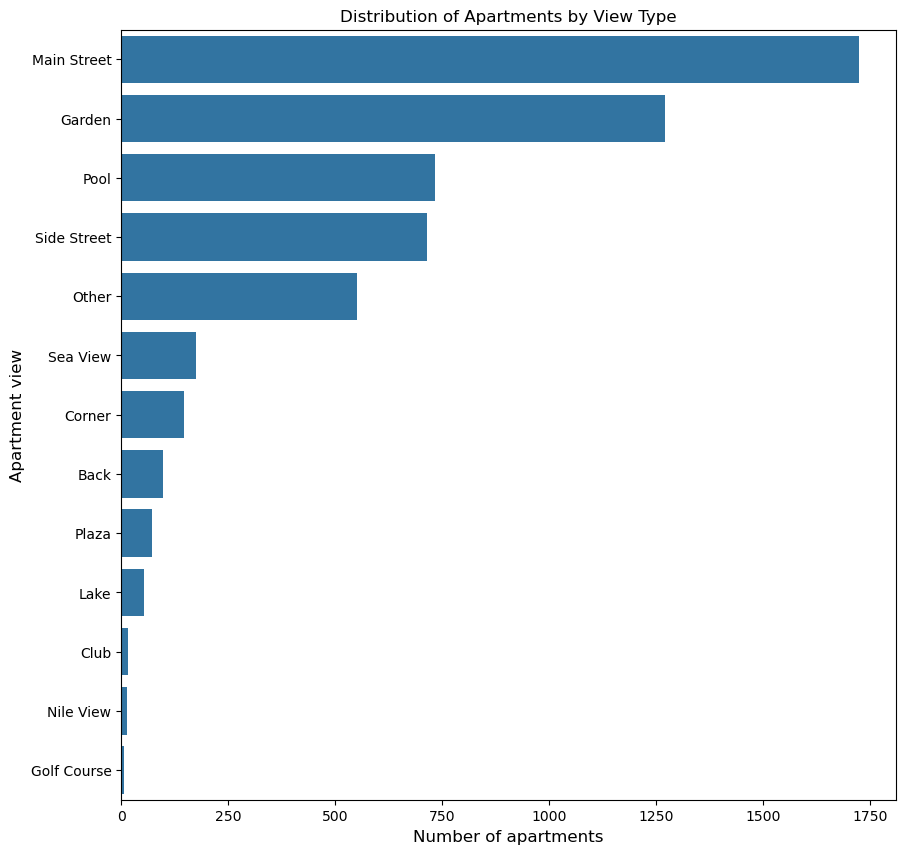

In [68]:
plt.figure(figsize=(10, 10))
sns.barplot(data = area_count, y = 'view', x = 'count')
plt.xlabel("Number of apartments", size = 12)
plt.ylabel("Apartment view", size = 12)
plt.title("Distribution of Apartments by View Type", size = 12)
plt.show()

## Insights:
- A lot of real estate apartments are in the main streets, which are good locations for middle class families.
- Followed by a less larger degree: gardens which provide magnificent atmosphere for families.
- Followed by a lesser degeree: pools and side streets, families do not find pools useful, as for side streets, it is not recommended to make apartments in side streets.
- Sea view, Corner, Back, Plaza, Lake, Club, Nile view and Golf course apartments have less market value due to their rarity.

# لو التقرير تسويقي:

- plt.title('Apartment Availability by View Type')

## لو التقرير تحليلي أكاديمي::

- plt.title('Frequency Distribution of Apartments by View Type')

# لو عرض لإدارة عليا:

- plt.title('Market Distribution of Apartments by View Type')


In [108]:
top_area = area_count['top'].str.replace(' m²', '').astype(int)

In [110]:
top_area

view
Main Street    150
Garden         130
Pool            58
Side Street    140
Other          130
Sea View        72
Corner         140
Back            73
Plaza          158
Lake           133
Club           212
Nile View      110
Golf Course    156
Name: top, dtype: int32

In [122]:
area_count

,count,unique,top,freq
view,,,,
Main Street,1725,196,150 m²,62
Garden,1272,192,130 m²,51
Pool,734,102,58 m²,41
Side Street,714,106,140 m²,61
Other,551,133,130 m²,28
Sea View,174,61,72 m²,37
Corner,148,53,140 m²,13
Back,97,36,73 m²,9
Plaza,73,28,158 m²,7


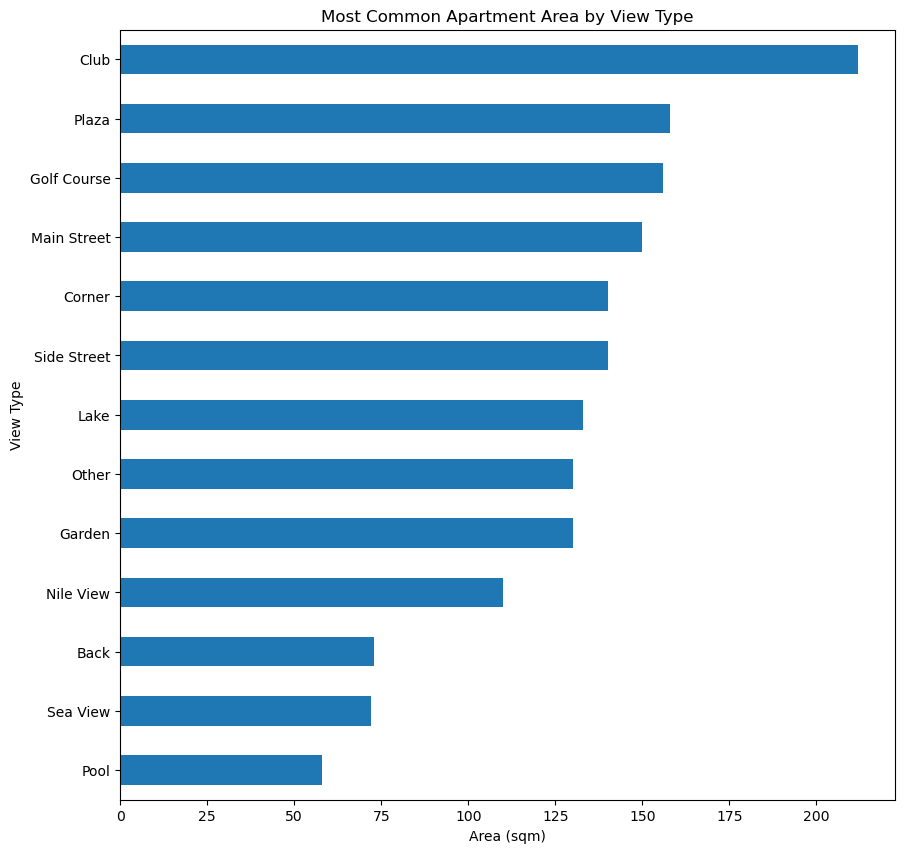

In [118]:
plt.figure(figsize=(10, 10))
top_area.sort_values().plot(kind='barh')
plt.title('Most Common Apartment Area by View Type')
plt.xlabel('Area (sqm)')
plt.ylabel('View Type')
plt.show()

## Insights:
- Clubs are the largest buildings by square area(212 square meters).
- Followed by a less larger degree: Plazas, Golf courses and Main street apartments. (158, 156 and 150 square meters respectively).
- Followed by a lesser degree: Corner apartments, Side street apartments, Lake, Gardens. (140, 140, 133 and 130 square meters respectively).
- Followed to a far less degree: Nile view apartments, Back, Sea view apartments and Pools (110, 73, 72 and 58 square meters respectively)
## Conclusions:
- Clubs provide larger features, lots of rooms with different sports and activities make a larger space for these buildings and thus high cost.
- Plazas provide a variety of activities: from retail stores, pedestrian areas and rooms for conferences.
- Golf courses' space consist of: a building with golf utlities and a large green space for playing golf.
- Main street apartments benefit from the large areas main streets provide, which gurrantees large buildings with a lot of floors with different apartments.
- Side streets provide small space for apartments with less floors and apartments compared to main street apartments.
- Gardens are secondary structures: Some buildings have them and some do not have them, building them is related to the project design than a primary utility.
- Nile view apartments occupy less space to provide an opportunity to see the Nile.
- Same thing for Sea view apartments.
- Pools occupy less space and can be built in villas or hotels or clubs.

In [126]:
characteristic

,view,area_sqm,floor_level,payment_method,rooms,bathrooms,finishing_type
0,Main Street,120 m²,3,Installments,2 rooms,3 bathroom,Semi Finished
1,Main Street,162 m²,6,Cash or Installments,3 rooms,2 bathroom,Semi Finished
2,Main Street,122 m²,4,Cash or Installments,3 rooms,1 bathroom,Semi Finished
3,Club,212 m²,13,Cash or Installments,4 rooms,3 bathroom,Extra Super Lux
4,Lake,135 m²,6,Cash or Installments,2 rooms,1 bathroom,Super Lux
...,...,...,...,...,...,...,...
5573,Garden,168 m²,5,Installments,3 rooms,3 bathroom,Semi Finished
5574,Side Street,180 m²,3,Cash,3 rooms,2 bathroom,Extra Super Lux
5575,Other,215 m²,7,Cash,3 rooms,2 bathroom,Semi Finished
5576,Main Street,400 m²,11,Cash,4 rooms,3 bathroom,Super Lux


In [ ]:
Number_of_floors = characterst